# Load Libraries

In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import math


from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [32]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Load and Preprocess Data

In [34]:
# ticker = 'AAPL'
# ticker = "GOOGL"
# ticker = "^IXIC"
ticker = "^GSPC"
df = yf.download(ticker, '2013-01-01')
scaler = StandardScaler()

[*********************100%***********************]  1 of 1 completed


In [35]:
from torch.utils.data import Dataset

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Transformer Model

In [36]:
class PositionalEncoding(nn.Module):
    """Positional encoding for Transformer to capture sequence order."""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # Add batch dimension
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerModel(nn.Module):
    """Transformer-based model for time series forecasting."""
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, output_dim, dropout=0.2):
        super(TransformerModel, self).__init__()
        
        self.d_model = d_model
        
        # Input projection layer
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder layers
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # Input shape: (batch, seq, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        # Output projection layer
        self.fc = nn.Linear(d_model, output_dim)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        
        # Project input to d_model dimensions
        x = self.input_projection(x) * math.sqrt(self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        x = self.dropout(x)
        
        # Pass through transformer encoder
        x = self.transformer_encoder(x)
        
        # Use the last time step's output for prediction
        x = x[:, -1, :]  # (batch_size, d_model)
        
        # Project to output dimension
        out = self.fc(x)
        
        return out

# Prepare Training Data

In [37]:
# -----------------------------------
# Set input window and forcast horizon length 
# -----------------------------------
input_window = 30
forecast_horizon = 1

# -----------------------------------
# Extract the target close prices
# -----------------------------------
close_prices = df['Close'].values


X = []
y = []

for i in range(len(close_prices) - input_window - forecast_horizon):
    X.append(close_prices[i:i+input_window])
    y.append(close_prices[i+input_window:i+input_window+forecast_horizon])

X = np.array(X)
y = np.array(y)

# -----------------------------------
# Data partitioning 
# -----------------------------------
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# -----------------------------------
# Scale data on training set
# -----------------------------------
scaler = MinMaxScaler()
scaler.fit(X_train.reshape(-1, 1))

X_train = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# -----------------------------------
# Convert data to tensors
# -----------------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


X_train = X_train.view(X_train.size(0), input_window, 1)
X_test = X_test.view(X_test.size(0), input_window, 1)


y_train = y_train.squeeze(-1)
y_test = y_test.squeeze(-1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: torch.Size([2615, 30, 1])
y_train: torch.Size([2615, 1])
X_test : torch.Size([654, 30, 1])
y_test : torch.Size([654, 1])


# Dataloader

In [38]:
from torch.utils.data import DataLoader

batch_size = 32  

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)


# Model Training

In [39]:
# Model hyperparameters
model = TransformerModel(
    input_dim=1,
    d_model=64,
    nhead=8,
    num_layers=2,
    dim_feedforward=128,
    output_dim=forecast_horizon,
    dropout=0.1
).to(device)

# -----------------------------------
# Training and evaluation
# -----------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 100

# -----------------------------------
# Training Loop 
# -----------------------------------

from copy import deepcopy
val_loader = test_loader
best_val_loss = float("inf")
patience = 15
patience_counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

for epoch in range(num_epochs):

    # Train
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # Step LR scheduler using validation loss
    scheduler.step(val_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break


# Restore best model
model.load_state_dict(best_model_weights)



Epoch 000 | Train Loss: 0.076134 | Val Loss: 0.155167
Epoch 001 | Train Loss: 0.090072 | Val Loss: 0.118623
Epoch 002 | Train Loss: 0.052924 | Val Loss: 0.100999
Epoch 003 | Train Loss: 0.040260 | Val Loss: 0.083397
Epoch 004 | Train Loss: 0.032078 | Val Loss: 0.073864
Epoch 005 | Train Loss: 0.027449 | Val Loss: 0.077545
Epoch 006 | Train Loss: 0.023733 | Val Loss: 0.065952
Epoch 007 | Train Loss: 0.024461 | Val Loss: 0.066543
Epoch 008 | Train Loss: 0.021914 | Val Loss: 0.069839
Epoch 009 | Train Loss: 0.019309 | Val Loss: 0.063348
Epoch 010 | Train Loss: 0.019229 | Val Loss: 0.054251
Epoch 011 | Train Loss: 0.019161 | Val Loss: 0.062798
Epoch 012 | Train Loss: 0.016068 | Val Loss: 0.059514
Epoch 013 | Train Loss: 0.015529 | Val Loss: 0.057322
Epoch 014 | Train Loss: 0.014871 | Val Loss: 0.057974
Epoch 015 | Train Loss: 0.014258 | Val Loss: 0.056088
Epoch 016 | Train Loss: 0.013051 | Val Loss: 0.058697
Epoch 017 | Train Loss: 0.015035 | Val Loss: 0.058923
Epoch 018 | Train Loss: 0.00

<All keys matched successfully>

## Model Evaluation and Visualization

In [40]:
# Evaluation

model.eval()

y_train_preds = []
y_train_true = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        y_train_preds.append(preds.cpu())
        y_train_true.append(y_batch.cpu())

y_train_pred = torch.cat(y_train_preds, dim=0)
y_train = torch.cat(y_train_true, dim=0)

y_test_preds = []
y_test_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        y_test_preds.append(preds.cpu())
        y_test_true.append(y_batch.cpu())

y_test_pred = torch.cat(y_test_preds, dim=0)
y_test = torch.cat(y_test_true, dim=0)


y_train_pred_np = y_train_pred.numpy()
y_train_np = y_train.numpy()
y_test_pred_np = y_test_pred.numpy()
y_test_np = y_test.numpy()


y_train_pred_inv = scaler.inverse_transform(y_train_pred_np)
y_train_inv = scaler.inverse_transform(y_train_np)
y_test_pred_inv = scaler.inverse_transform(y_test_pred_np)
y_test_inv = scaler.inverse_transform(y_test_np)


train_rmse = root_mean_squared_error(
    y_train_np, y_train_pred_np
)

test_rmse = root_mean_squared_error(
   y_test_np, y_test_pred_np
)

from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = y_test_np
y_pred = y_test_pred_np

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"MAE:  {mae:.4f}")


print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return 100 * np.mean(np.where(denominator == 0, 0, diff / denominator))

print(f"SMAPE: {smape(y_true, y_pred):.2f}%")


MSE:  0.0221
MAE:  0.1184
Train RMSE: 0.0179
Test RMSE:  0.1487
SMAPE: 9.16%


In [41]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_train_flat = y_train.reshape(-1)
y_train_pred_flat = y_train_pred.reshape(-1)

y_test_flat = y_test.reshape(-1)
y_test_pred_flat = y_test_pred.reshape(-1)

# Evaluation metrics
train_rmse = mean_squared_error(y_train_flat, y_train_pred_flat)
test_rmse  = mean_squared_error(y_test_flat, y_test_pred_flat)

mse = mean_squared_error(y_test_flat, y_test_pred_flat)
mae = mean_absolute_error(y_test_flat, y_test_pred_flat)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"MAE:        {mae:.4f}")


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return 100 * np.mean(np.where(denominator == 0, 0, diff / denominator))

print(f"SMAPE:      {smape(y_test_flat, y_test_pred_flat):.4f}%")


Train RMSE: 0.0003
Test RMSE:  0.0221
MSE:        0.0221
MAE:        0.1184
SMAPE:      9.1602%


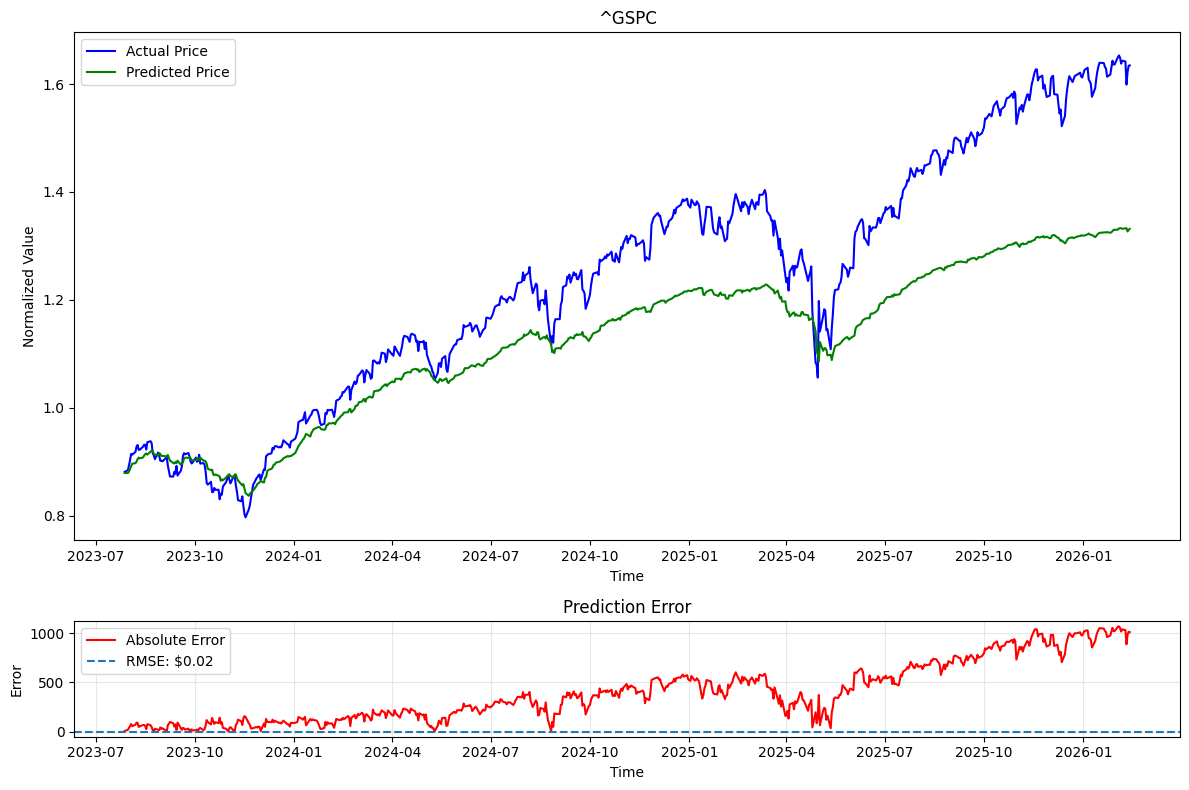

In [42]:
# -----------------------------------
# Visualization 
# -----------------------------------
seq_length = 30
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(4, 1)


test_start_idx = len(df) - len(y_test) - seq_length
test_dates = df.index[test_start_idx + seq_length : test_start_idx + seq_length + len(y_test)]


ax1 = fig.add_subplot(gs[:3, 0])

ax1.plot(
    test_dates,
    y_test_np,
    label='Actual Price',
    color='blue'
)

ax1.plot(
    test_dates,
    y_test_pred_np,
    label='Predicted Price',
    color='green'
)

ax1.set_title(f'{ticker}')
ax1.set_xlabel('Time')
ax1.set_ylabel('Normalized Value')
ax1.legend()
# ax1.grid(True, alpha=0.3)

# --- Plot: Absolute Error ---
ax2 = fig.add_subplot(gs[3, 0])

error = np.abs(y_test_inv[:, 0] - y_test_pred_inv[:, 0])

ax2.plot(
    test_dates,
    error,
    color='red',
    label='Absolute Error'
)

ax2.axhline(
    test_rmse,
    linestyle='--',
    label=f'RMSE: ${test_rmse:.2f}'
)

ax2.set_title('Prediction Error')
ax2.set_xlabel('Time')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
